# Laboratorio 7 - Regresión Logística

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import random
import statsmodels.api as sm
import statsmodels.stats.diagnostic as smd
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
import statsmodels.stats.diagnostic as diag
from sklearn.linear_model import LogisticRegression
import pyreadr
import random

#Metrics
from sklearn.metrics import make_scorer, accuracy_score,precision_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score ,precision_score,recall_score,f1_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import learning_curve
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [12]:
random.seed(42)
np.random.seed(42)

result = pyreadr.read_r('listings.RData')
df = result[list(result.keys())[0]]

### Carga de datos

In [13]:
result = pyreadr.read_r('listings.RData')
df = result['listings']

# Limpiar price
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df = df.dropna(subset=['price'])

df.shape

(76246, 80)

In [14]:
cols_to_keep = [
    'price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
    'room_type', 'minimum_nights', 'number_of_reviews',
    'review_scores_rating', 'reviews_per_month'
]

df_model = df[cols_to_keep].copy().dropna()

# Encoding de room_type
df_model = pd.get_dummies(df_model, columns=['room_type'], drop_first=True)

In [15]:
# Mismos bins que labs anteriores
bins   = [0, 100, 250, float('inf')]
labels = ['economica', 'media', 'cara']

df_model['precio_cat'] = pd.cut(df_model['price'], bins=bins, labels=labels)

# Variable dicotómica para cada categoría
df_model['es_cara']      = (df_model['precio_cat'] == 'cara').astype(int)
df_model['es_media']     = (df_model['precio_cat'] == 'media').astype(int)
df_model['es_economica'] = (df_model['precio_cat'] == 'economica').astype(int)

print("Distribución de categorías:")
print(df_model['precio_cat'].value_counts())
print("\nVerificación de variables dicotómicas:")
print(df_model[['es_cara','es_media','es_economica']].head(10))

Distribución de categorías:
precio_cat
media        30411
cara         20841
economica    11470
Name: count, dtype: int64

Verificación de variables dicotómicas:
   es_cara  es_media  es_economica
0        0         0             1
1        0         1             0
2        0         0             1
3        0         1             0
4        0         0             1
5        0         0             1
6        1         0             0
7        0         1             0
8        0         1             0
9        0         1             0


# 1. Creación de variables dicotómicas

Se generaron tres variables dicotómicas a partir de la variable categórica precio_cat, con el objetivo de transformar el problema en clasificación binaria. Cada variable toma el valor de 1 cuando la observación pertenece a la categoría correspondiente (cara, media o económica) y 0 en caso contrario.

In [16]:
X = df_model.drop(columns=['price', 'precio_cat', 'es_cara', 'es_media', 'es_economica'])
y_cara      = df_model['es_cara']
y_media     = df_model['es_media']
y_economica = df_model['es_economica']

# 2. Definir y usar conjuntos de entrenamiento y prueba

Conjuntos de entrenamiento y prueba para casas caras:

In [17]:
# Split 70/30 con misma semilla
X_train, X_test, y_train_cara, y_test_cara = train_test_split(
    X, y_cara, test_size=0.3, random_state=42, stratify=y_cara
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("\nBalance en entrenamiento:")
print(y_train_cara.value_counts(normalize=True).round(3))

Train: (43905, 11) | Test: (18817, 11)

Balance en entrenamiento:
es_cara
0    0.668
1    0.332
Name: proportion, dtype: float64


# 3. Elaborar modelo de Regresión Logística solamente con train

Usando validación cruzada:

In [18]:
logReg = LogisticRegression(solver='liblinear')

#parámetros para validación cruzada
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],   # regularización
    'penalty': ['l1', 'l2']         # tipo de regularización
}

#validación cruzada
grid = GridSearchCV(
    logReg,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train_cara) #solo usa train

best_model = grid.best_estimator_

print("Mejores parámetros:", grid.best_params_)

y_proba2 = best_model.predict_proba(X_test)[:, 1]

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/u

Mejores parámetros: {'C': 10, 'penalty': 'l1'}


In [19]:
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test_cara, y_pred)

print("Accuracy (Test):", accuracy)

Accuracy (Test): 0.7899771483233247


In [20]:
print("Matriz de confusión:")
print(confusion_matrix(y_test_cara, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test_cara, y_pred))

Matriz de confusión:
[[11187  1378]
 [ 2574  3678]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     12565
           1       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817



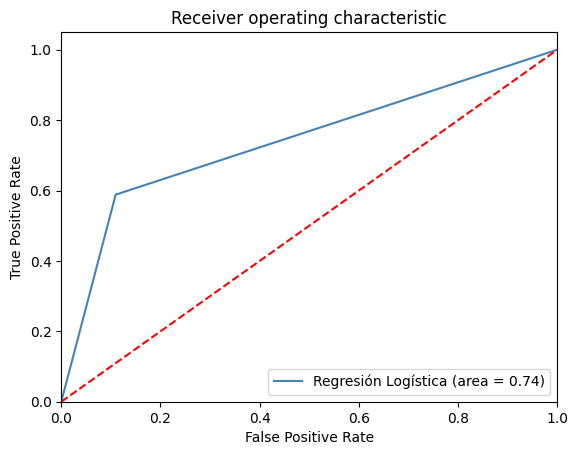

In [21]:
logit_roc_auc = roc_auc_score(y_test_cara, y_pred)
fpr, tpr, thresholds = roc_curve(y_test_cara, y_pred)
plt.figure()
plt.plot(fpr, tpr, label='Regresión Logística (area = %0.2f)' % logit_roc_auc, color="steelblue")
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver operating characteristic')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

# 4. Revisar Multicolinealidad

Para analizar la multicolinealidad, se utilizó un modelo de regresión logística con regularización L1 (Lasso), el cual permite identificar variables redundantes al reducir coeficientes a cero.

Los resultados muestran que ninguna variable fue eliminada, ya que todos los coeficientes son distintos de cero. Esto sugiere que no existe multicolinealidad severa en el conjunto de variables, aunque podrían existir relaciones moderadas entre variables asociadas al tamaño del alojamiento, como número de camas, habitaciones y capacidad.

In [22]:
from sklearn.linear_model import LogisticRegression

lasso_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1,
    random_state=42
)

lasso_model.fit(X_train, y_train_cara)

coef_df = pd.DataFrame({
    'Variable': X_train.columns,
    'Coeficiente': lasso_model.coef_[0]
})

print(coef_df.sort_values(by='Coeficiente'))

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


                  Variable  Coeficiente
10   room_type_Shared room    -2.867188
9   room_type_Private room    -0.449889
7        reviews_per_month    -0.413022
4           minimum_nights    -0.020724
5        number_of_reviews    -0.000373
3                     beds     0.099456
2                 bedrooms     0.142711
0             accommodates     0.193062
6     review_scores_rating     0.546281
1                bathrooms     0.709530
8     room_type_Hotel room     1.784852


In [23]:
corr = X_train.corr()
print(corr)

                        accommodates  ...  room_type_Shared room
accommodates                1.000000  ...              -0.047831
bathrooms                   0.693761  ...               0.036195
bedrooms                    0.815683  ...              -0.000294
beds                        0.854733  ...              -0.002007
minimum_nights             -0.113108  ...               0.007849
number_of_reviews          -0.097409  ...              -0.004336
review_scores_rating        0.061179  ...              -0.023040
reviews_per_month          -0.037690  ...              -0.004131
room_type_Hotel room       -0.011235  ...              -0.003157
room_type_Private room     -0.316226  ...              -0.019895
room_type_Shared room      -0.047831  ...               1.000000

[11 rows x 11 columns]


Se realizó un análisis de correlación mediante una matriz de correlación. Los resultados evidencian la existencia de correlaciones positivas fuertes entre variables relacionadas con el tamaño del alojamiento, con valores superiores a 0.75. Sin embargo, no se observan correlaciones extremadamente altas cercanas a 1, por lo que no se considera un problema severo.

Asimismo, se identificó una correlación moderada entre el número total de reseñas y las reseñas por mes, lo cual también resulta coherente desde el punto de vista conceptual. Por otro lado, variables como el tipo de habitación y las calificaciones presentan bajas correlaciones con el resto, lo que indica que aportan información adicional relevante al modelo.

Estos resultados son consistentes con el análisis realizado mediante regularización L1, donde no se eliminaron variables, lo que sugiere que el modelo no se ve afectado significativamente por multicolinealidad y se adapta adecuadamente a los datos.

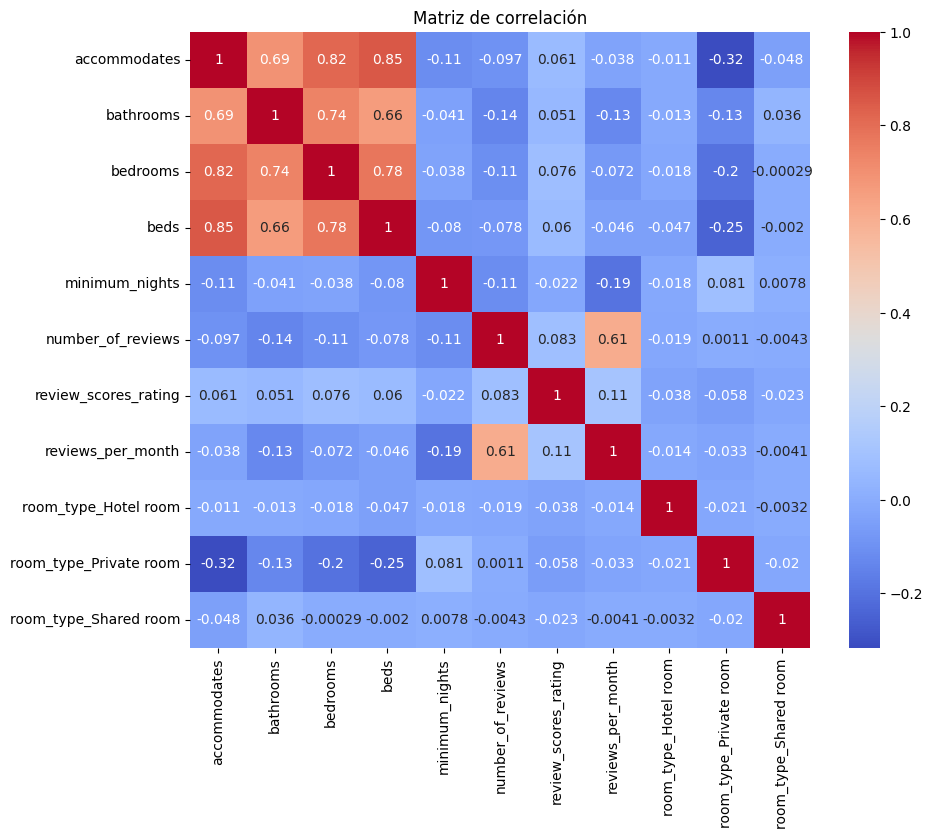

In [24]:
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matriz de correlación")
plt.show()

## 5. Eficiencia del algoritmo para clasificar.

In [25]:
# 1. Utilizar el modelo (ya entrenado como best_model) con el conjunto de prueba
y_pred = best_model.predict(X_test)

# 2. Determinar la eficiencia global (Accuracy)
accuracy = accuracy_score(y_test_cara, y_pred)
print(f"Eficiencia (Accuracy) del algoritmo en el conjunto de prueba: {accuracy:.4f}\n")

# 3. Mostrar la Matriz de Confusión para ver los Verdaderos Positivos, Falsos Positivos, etc.
print("Matriz de confusión:")
print(confusion_matrix(y_test_cara, y_pred))

# 4. Mostrar el reporte de clasificación (Muestra Precisión, Recall y F1-Score por cada clase)
print("\nReporte de clasificación detallado:")
print(classification_report(y_test_cara, y_pred))


Eficiencia (Accuracy) del algoritmo en el conjunto de prueba: 0.7900

Matriz de confusión:
[[11187  1378]
 [ 2574  3678]]

Reporte de clasificación detallado:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85     12565
           1       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817



## 6. Overfitting y Curvas

Error en Entrenamiento: 0.2032
Error en Prueba: 0.2100
Conclusión: NO hay sobreajuste evidente. El modelo generaliza bien (Buen ajuste).
--------------------------------------------------


/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

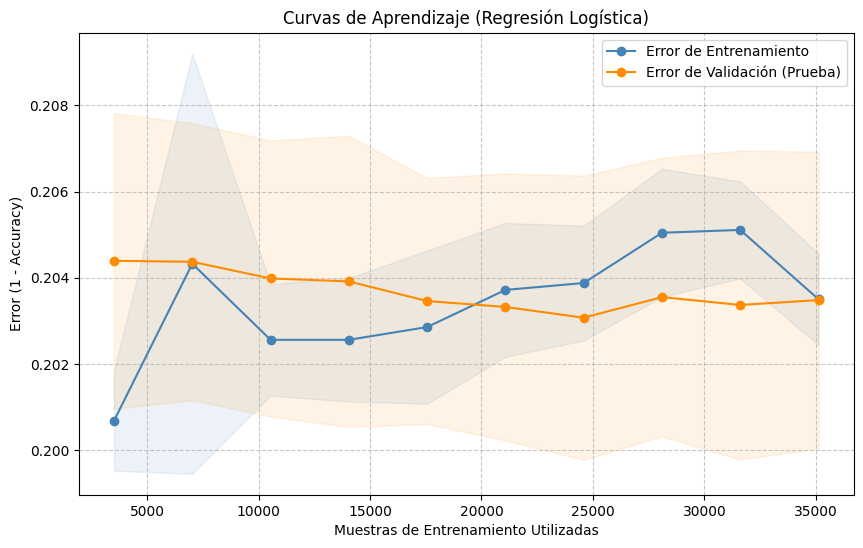

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve
from sklearn.metrics import accuracy_score

# 1. Calcular errores de entrenamiento y prueba
y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

# El error es 1 - el accuracy (si clasificó bien el 80%, el error es el 20%)
train_error = 1 - accuracy_score(y_train_cara, y_train_pred)
test_error = 1 - accuracy_score(y_test_cara, y_test_pred)

print(f"Error en Entrenamiento: {train_error:.4f}")
print(f"Error en Prueba: {test_error:.4f}")

# Explicación automatizada basada en la diferencia
diferencia = test_error - train_error
if diferencia > 0.10:
    print("Conclusión: Es posible que haya SOBREAJUSTE (la brecha entre los errores es grande).")
elif train_error > 0.30 and test_error > 0.30:
    print("Conclusión: Es posible que haya SUBAPRENDIZAJE (Underfitting), ya que ambos errores son altos.")
else:
    print("Conclusión: NO hay sobreajuste evidente. El modelo generaliza bien (Buen ajuste).")

print("-" * 50)

# 2. Generar las curvas de aprendizaje
# Nota: Utilizamos validación cruzada para que las curvas sean más estables
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train_cara, cv=5, scoring='accuracy', 
    n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 10)
)

# Se obtienen los errores (1 - accuracy)
train_errors_mean = 1 - np.mean(train_scores, axis=1)
train_errors_std = np.std(train_scores, axis=1)
test_errors_mean = 1 - np.mean(test_scores, axis=1)
test_errors_std = np.std(test_scores, axis=1)

# Dibujar la gráfica
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_errors_mean, 'o-', color="steelblue", label="Error de Entrenamiento")
plt.plot(train_sizes, test_errors_mean, 'o-', color="darkorange", label="Error de Validación (Prueba)")

# Sombras de desviación estándar (opcional, para ver la varianza)
plt.fill_between(train_sizes, train_errors_mean - train_errors_std,
                 train_errors_mean + train_errors_std, alpha=0.1, color="steelblue")
plt.fill_between(train_sizes, test_errors_mean - test_errors_std,
                 test_errors_mean + test_errors_std, alpha=0.1, color="darkorange")

plt.title("Curvas de Aprendizaje (Regresión Logística)")
plt.xlabel("Muestras de Entrenamiento Utilizadas")
plt.ylabel("Error (1 - Accuracy)")
plt.legend(loc="best")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()


## 7. Tuneo Parámetros

In [31]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Parámetros a tunear
param_grid = {
    'solver':  ['liblinear', 'lbfgs', 'newton-cg'],
    'penalty': ['l1', 'l2'],        # L1 = LASSO, L2 = Ridge
    'C':       [0.01, 0.1, 1, 10, 100]  # inverso de regularización
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train_cara)

print("Mejores parámetros:", grid_search.best_params_)
print("Mejor accuracy CV: ", round(grid_search.best_score_, 4))

best_model_tuned = grid_search.best_estimator_

# Evaluar en test
y_pred_tuned = best_model_tuned.predict(X_test)
print("\nAccuracy en test (modelo tuneado):", round(accuracy_score(y_test_cara, y_pred_tuned), 4))
print(classification_report(y_test_cara, y_pred_tuned, target_names=['No cara', 'Cara']))

/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/u

Mejores parámetros: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Mejor accuracy CV:  0.7965

Accuracy en test (modelo tuneado): 0.79
              precision    recall  f1-score   support

     No cara       0.81      0.89      0.85     12565
        Cara       0.73      0.59      0.65      6252

    accuracy                           0.79     18817
   macro avg       0.77      0.74      0.75     18817
weighted avg       0.78      0.79      0.78     18817

